In [40]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ============================================================
# 1. Paths
# ============================================================

INPUT_PATH = Path("../data/processed/neutral_scoring_prepared/neutral_scoring_input_v1.tsv")

OUTPUT_DIR = Path("../results/directional_neutral_scoring_results")
OUTPUT_DIR.mkdir(exist_ok=True)

SCORED_OUTPUT = OUTPUT_DIR / "directional_neutral_deviation_scores_v1.tsv"
THRESHOLD_OUTPUT = OUTPUT_DIR / "directional_neutral_deviation_thresholds_v1.tsv"
ENRICHMENT_OUTPUT = OUTPUT_DIR / "directional_posthoc_group_enrichment_v1.tsv"
SCORE_COMPONENTS_OUTPUT = OUTPUT_DIR / "directional_score_components_summary_v1.tsv"

# ============================================================
# 2. Load input
# ============================================================

df = pd.read_csv(INPUT_PATH, sep="\t", low_memory=False)

print("Input shape:", df.shape)

print("\nAnalysis group distribution:")
print(df["analysis_group"].value_counts(dropna=False))

Input shape: (49704, 40)

Analysis group distribution:
analysis_group
unlabeled_or_other            41280
neutral_reference              8284
article_pathogenic_posthoc       84
disease_suspected_posthoc        56
Name: count, dtype: int64


In [41]:
# ============================================================
# 3. Required columns
# ============================================================

id_cols = [
    "variant_id",
    "position",
    "reference",
    "alternate",
]

label_cols = [
    "validation_label",
    "is_neutral_dataset8",
    "is_pathogenic_dataset9",
    "is_disease_suspected_dataset3",
    "analysis_group",
]

raw_feature_cols = [
    "mlc_score",

    "gnomad_observed",
    "helix_observed",

    "gnomad_homoplasmic_af",
    "gnomad_heteroplasmic_af",
    "gnomad_combined_af_simple",

    "helix_af_hom",
    "helix_af_het",

    "gnomad_max_heteroplasmy",
    "helix_mean_arf",
    "helix_max_arf",

    "pop_af_hom_max",
    "pop_af_het_max",
    "pop_af_max",
    "pop_af_hom_sum",
    "pop_af_het_sum",
    "pop_af_sum",

    "observed_in_any_population_db",
    "observed_in_both_population_dbs",
    "pop_max_heteroplasmy_or_arf",
]

required_cols = id_cols + label_cols + raw_feature_cols

missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

work = df.copy()

for col in raw_feature_cols:
    work[col] = pd.to_numeric(work[col], errors="coerce")

missing_summary = work[raw_feature_cols].isna().sum()
missing_summary = missing_summary[missing_summary > 0]

if len(missing_summary) > 0:
    raise ValueError(f"Missing values in raw features:\n{missing_summary}")

In [42]:
# ============================================================
# 4. Directional feature engineering
# ============================================================

eps = 1e-12

# ------------------------------------------------------------
# Population rarity features
# Чем ниже AF, тем выше rarity score.
# Если AF = 0, score будет большим.
# ------------------------------------------------------------

work["rarity_pop_af_max"] = -np.log10(work["pop_af_max"] + eps)
work["rarity_pop_af_hom_max"] = -np.log10(work["pop_af_hom_max"] + eps)
work["rarity_pop_af_het_max"] = -np.log10(work["pop_af_het_max"] + eps)

work["rarity_gnomad_combined_af"] = -np.log10(
    work["gnomad_combined_af_simple"] + eps
)

work["rarity_gnomad_hom_af"] = -np.log10(
    work["gnomad_homoplasmic_af"] + eps
)

work["rarity_gnomad_het_af"] = -np.log10(
    work["gnomad_heteroplasmic_af"] + eps
)

work["rarity_helix_hom_af"] = -np.log10(
    work["helix_af_hom"] + eps
)

work["rarity_helix_het_af"] = -np.log10(
    work["helix_af_het"] + eps
)

# ------------------------------------------------------------
# Observed flags, but directionally encoded
# Не наблюдается в population DB -> больше suspicious
# ------------------------------------------------------------

work["not_observed_in_gnomad"] = 1 - work["gnomad_observed"].astype(int)
work["not_observed_in_helix"] = 1 - work["helix_observed"].astype(int)
work["not_observed_in_any_population_db"] = (
    1 - work["observed_in_any_population_db"].astype(int)
)

work["not_observed_in_both_population_dbs"] = (
    1 - work["observed_in_both_population_dbs"].astype(int)
)

# ------------------------------------------------------------
# Homoplasmy rarity / absence
# Частые homoplasmic observations обычно поддерживают neutrality.
# Поэтому низкая homoplasmic AF -> выше score.
# ------------------------------------------------------------

work["no_homoplasmic_population_signal"] = (
    (work["gnomad_homoplasmic_af"] == 0)
    & (work["helix_af_hom"] == 0)
).astype(int)

# ------------------------------------------------------------
# Heteroplasmy / ARF
# Здесь осторожно: высокий max heteroplasmy/ARF может означать,
# что вариант встречается в population data на заметном уровне.
# Поэтому это не обязательно pathogenic-like.
#
# Для directional baseline я бы использовал его как "population tolerance"
# в обратную сторону: чем выше observed heteroplasmy/ARF, тем ниже suspicious.
# ------------------------------------------------------------

work["low_population_heteroplasmy_or_arf"] = -np.log10(
    work["pop_max_heteroplasmy_or_arf"] + eps
)

# ------------------------------------------------------------
# Cap extreme rarity values
# AF=0 даёт -log10(1e-12)=12.
# Это нормально, но можно ограничить верхний хвост,
# чтобы нулевые AF не доминировали полностью.
# ------------------------------------------------------------

rarity_cols_to_cap = [
    "rarity_pop_af_max",
    "rarity_pop_af_hom_max",
    "rarity_pop_af_het_max",
    "rarity_gnomad_combined_af",
    "rarity_gnomad_hom_af",
    "rarity_gnomad_het_af",
    "rarity_helix_hom_af",
    "rarity_helix_het_af",
    "low_population_heteroplasmy_or_arf",
]

for col in rarity_cols_to_cap:
    work[col] = work[col].clip(lower=0, upper=12)

In [43]:
# ============================================================
# 5. Define directional feature sets
# ============================================================

directional_feature_sets = {
    "directional_mlc_only": [
        "mlc_score",
    ],

    "directional_population_only": [
        "rarity_pop_af_max",
        "rarity_pop_af_hom_max",
        "rarity_pop_af_het_max",

        "rarity_gnomad_combined_af",
        "rarity_gnomad_hom_af",
        "rarity_gnomad_het_af",

        "rarity_helix_hom_af",
        "rarity_helix_het_af",

        "not_observed_in_gnomad",
        "not_observed_in_helix",
        "not_observed_in_any_population_db",
        "not_observed_in_both_population_dbs",

        "no_homoplasmic_population_signal",
        "low_population_heteroplasmy_or_arf",
    ],
}

directional_feature_sets["directional_combined"] = (
    directional_feature_sets["directional_mlc_only"]
    + directional_feature_sets["directional_population_only"]
)

# Remove duplicates
for name, cols in directional_feature_sets.items():
    directional_feature_sets[name] = list(dict.fromkeys(cols))

# Safety checks
for name, cols in directional_feature_sets.items():
    missing = [col for col in cols if col not in work.columns]
    if missing:
        raise ValueError(f"{name}: missing columns: {missing}")

    non_numeric = [
        col for col in cols
        if not pd.api.types.is_numeric_dtype(work[col])
    ]
    if non_numeric:
        raise ValueError(f"{name}: non-numeric columns: {non_numeric}")

    missing_values = work[cols].isna().sum()
    missing_values = missing_values[missing_values > 0]

    if len(missing_values) > 0:
        raise ValueError(f"{name}: missing values:\n{missing_values}")

    print(f"{name}: {len(cols)} features")

directional_mlc_only: 1 features
directional_population_only: 14 features
directional_combined: 15 features


In [44]:
# ============================================================
# 6. Directional score calculation
# ============================================================

def compute_directional_score(data, feature_cols, score_name):
    neutral_mask = data["analysis_group"] == "neutral_reference"

    X_neutral = data.loc[neutral_mask, feature_cols].copy()
    X_all = data[feature_cols].copy()

    scaler = StandardScaler()
    scaler.fit(X_neutral)

    Z_all = scaler.transform(X_all)

    z_cols = [f"{score_name}__z__{col}" for col in feature_cols]
    z_df = pd.DataFrame(
        Z_all,
        columns=z_cols,
        index=data.index,
    )

    # Directional score:
    # high value = more shifted above neutral distribution
    score = z_df.mean(axis=1)

    return score, z_df, scaler


scored = work.copy()
all_z_dfs = []

for score_name, cols in directional_feature_sets.items():
    score, z_df, scaler = compute_directional_score(
        scored,
        cols,
        score_name,
    )

    scored[f"{score_name}_score"] = score

    scored[f"{score_name}_rank"] = (
        scored[f"{score_name}_score"]
        .rank(method="min", ascending=False)
        .astype(int)
    )

    scored[f"{score_name}_percentile"] = (
        scored[f"{score_name}_score"]
        .rank(method="average", pct=True)
    )

    all_z_dfs.append(z_df)

z_all = pd.concat(all_z_dfs, axis=1)

In [45]:
# ============================================================
# 7. Thresholds based on neutral reference distribution
# ============================================================

threshold_rows = []

neutral_mask = scored["analysis_group"] == "neutral_reference"

for score_name in directional_feature_sets:
    score_col = f"{score_name}_score"

    neutral_scores = scored.loc[neutral_mask, score_col]

    for q in [0.90, 0.95, 0.99]:
        threshold_name = f"T{int(q * 100)}"
        threshold = neutral_scores.quantile(q)

        above_col = f"{score_name}_above_{threshold_name}"

        scored[above_col] = (
            scored[score_col] > threshold
        ).astype(int)

        threshold_rows.append({
            "score_name": score_name,
            "threshold_name": threshold_name,
            "neutral_quantile": q,
            "threshold_value": threshold,
            "n_neutral_above_threshold": int((neutral_scores > threshold).sum()),
            "fraction_neutral_above_threshold": float((neutral_scores > threshold).mean()),
        })

threshold_df = pd.DataFrame(threshold_rows)

threshold_df.to_csv(THRESHOLD_OUTPUT, sep="\t", index=False)

print("\nThresholds:")
print(threshold_df)

print("\nSaved thresholds:")
print(THRESHOLD_OUTPUT)


Thresholds:
                    score_name threshold_name  neutral_quantile  \
0         directional_mlc_only            T90              0.90   
1         directional_mlc_only            T95              0.95   
2         directional_mlc_only            T99              0.99   
3  directional_population_only            T90              0.90   
4  directional_population_only            T95              0.95   
5  directional_population_only            T99              0.99   
6         directional_combined            T90              0.90   
7         directional_combined            T95              0.95   
8         directional_combined            T99              0.99   

   threshold_value  n_neutral_above_threshold  \
0         1.657163                        828   
1         2.358105                        413   
2         3.548626                         81   
3         1.350210                          0   
4         1.350210                          0   
5         1.350210    

In [46]:
# ============================================================
# 7. Thresholds based on neutral reference distribution
# ============================================================

threshold_rows = []

neutral_mask = scored["analysis_group"] == "neutral_reference"

for score_name in directional_feature_sets:
    score_col = f"{score_name}_score"

    neutral_scores = scored.loc[neutral_mask, score_col]

    for q in [0.90, 0.95, 0.99]:
        threshold_name = f"T{int(q * 100)}"
        threshold = neutral_scores.quantile(q)

        above_col = f"{score_name}_above_{threshold_name}"

        scored[above_col] = (
            scored[score_col] > threshold
        ).astype(int)

        threshold_rows.append({
            "score_name": score_name,
            "threshold_name": threshold_name,
            "neutral_quantile": q,
            "threshold_value": threshold,
            "n_neutral_above_threshold": int((neutral_scores > threshold).sum()),
            "fraction_neutral_above_threshold": float((neutral_scores > threshold).mean()),
        })

threshold_df = pd.DataFrame(threshold_rows)

threshold_df.to_csv(THRESHOLD_OUTPUT, sep="\t", index=False)

print("\nThresholds:")
print(threshold_df)

print("\nSaved thresholds:")
print(THRESHOLD_OUTPUT)


Thresholds:
                    score_name threshold_name  neutral_quantile  \
0         directional_mlc_only            T90              0.90   
1         directional_mlc_only            T95              0.95   
2         directional_mlc_only            T99              0.99   
3  directional_population_only            T90              0.90   
4  directional_population_only            T95              0.95   
5  directional_population_only            T99              0.99   
6         directional_combined            T90              0.90   
7         directional_combined            T95              0.95   
8         directional_combined            T99              0.99   

   threshold_value  n_neutral_above_threshold  \
0         1.657163                        828   
1         2.358105                        413   
2         3.548626                         81   
3         1.350210                          0   
4         1.350210                          0   
5         1.350210    

In [47]:
# ============================================================
# 8. Post-hoc enrichment
# ============================================================

posthoc_groups = [
    "neutral_reference",
    "unlabeled_or_other",
    "article_pathogenic_posthoc",
    "disease_suspected_posthoc",
]

enrichment_rows = []

for score_name in directional_feature_sets:
    for threshold_name in ["T90", "T95", "T99"]:
        flag_col = f"{score_name}_above_{threshold_name}"

        for group in posthoc_groups:
            group_mask = scored["analysis_group"] == group

            n_group = int(group_mask.sum())
            n_above = int(scored.loc[group_mask, flag_col].sum())

            frac_above = n_above / n_group if n_group > 0 else np.nan

            # Enrichment relative to expected neutral fraction
            expected = {
                "T90": 0.10,
                "T95": 0.05,
                "T99": 0.01,
            }[threshold_name]

            enrichment_rows.append({
                "score_name": score_name,
                "threshold_name": threshold_name,
                "analysis_group": group,
                "n_group": n_group,
                "n_above_threshold": n_above,
                "fraction_above_threshold": frac_above,
                "expected_neutral_fraction": expected,
                "fold_enrichment_vs_neutral_expectation": (
                    frac_above / expected if expected > 0 else np.nan
                ),
            })

enrichment_df = pd.DataFrame(enrichment_rows)

enrichment_df.to_csv(ENRICHMENT_OUTPUT, sep="\t", index=False)

print("\nPost-hoc enrichment:")
print(enrichment_df)

print("\nSaved enrichment:")
print(ENRICHMENT_OUTPUT)


Post-hoc enrichment:
                     score_name threshold_name              analysis_group  \
0          directional_mlc_only            T90           neutral_reference   
1          directional_mlc_only            T90          unlabeled_or_other   
2          directional_mlc_only            T90  article_pathogenic_posthoc   
3          directional_mlc_only            T90   disease_suspected_posthoc   
4          directional_mlc_only            T95           neutral_reference   
5          directional_mlc_only            T95          unlabeled_or_other   
6          directional_mlc_only            T95  article_pathogenic_posthoc   
7          directional_mlc_only            T95   disease_suspected_posthoc   
8          directional_mlc_only            T99           neutral_reference   
9          directional_mlc_only            T99          unlabeled_or_other   
10         directional_mlc_only            T99  article_pathogenic_posthoc   
11         directional_mlc_only           

In [48]:
# ============================================================
# 9. Save scored table
# ============================================================

score_cols = []

for score_name in directional_feature_sets:
    score_cols.extend([
        f"{score_name}_score",
        f"{score_name}_rank",
        f"{score_name}_percentile",
        f"{score_name}_above_T90",
        f"{score_name}_above_T95",
        f"{score_name}_above_T99",
    ])

directional_component_cols = [
    "rarity_pop_af_max",
    "rarity_pop_af_hom_max",
    "rarity_pop_af_het_max",

    "rarity_gnomad_combined_af",
    "rarity_gnomad_hom_af",
    "rarity_gnomad_het_af",

    "rarity_helix_hom_af",
    "rarity_helix_het_af",

    "not_observed_in_gnomad",
    "not_observed_in_helix",
    "not_observed_in_any_population_db",
    "not_observed_in_both_population_dbs",

    "no_homoplasmic_population_signal",
    "low_population_heteroplasmy_or_arf",
]

base_cols = (
    id_cols
    + label_cols
)

output_cols = (
    base_cols
    + score_cols
    + ["mlc_score"]
    + directional_component_cols
)

scored[output_cols].to_csv(SCORED_OUTPUT, sep="\t", index=False)

print("\nSaved scored table:")
print(SCORED_OUTPUT)


Saved scored table:
../results/directional_neutral_scoring_results/directional_neutral_deviation_scores_v1.tsv


In [49]:
# ============================================================
# 10. Component summary by analysis group
# ============================================================

summary_rows = []

component_cols_for_summary = [
    "mlc_score",
] + directional_component_cols + [
    "directional_mlc_only_score",
    "directional_population_only_score",
    "directional_combined_score",
]

for group in posthoc_groups:
    group_df = scored[scored["analysis_group"] == group]

    for col in component_cols_for_summary:
        if col not in group_df.columns:
            continue

        summary_rows.append({
            "analysis_group": group,
            "feature": col,
            "n": group_df[col].notna().sum(),
            "mean": group_df[col].mean(),
            "median": group_df[col].median(),
            "q25": group_df[col].quantile(0.25),
            "q75": group_df[col].quantile(0.75),
            "min": group_df[col].min(),
            "max": group_df[col].max(),
        })

component_summary = pd.DataFrame(summary_rows)

component_summary.to_csv(
    SCORE_COMPONENTS_OUTPUT,
    sep="\t",
    index=False,
)

print("\nSaved score components summary:")
print(SCORE_COMPONENTS_OUTPUT)


Saved score components summary:
../results/directional_neutral_scoring_results/directional_score_components_summary_v1.tsv


In [50]:
# ============================================================
# 11. Top-ranked variants for manual inspection
# ============================================================

TOP_DIR = OUTPUT_DIR / "top_ranked_variants"
TOP_DIR.mkdir(exist_ok=True)

for score_name in directional_feature_sets:
    score_col = f"{score_name}_score"

    top_cols = [
        "variant_id",
        "position",
        "reference",
        "alternate",
        "validation_label",
        "analysis_group",
        score_col,
        f"{score_name}_rank",
        f"{score_name}_percentile",
        f"{score_name}_above_T90",
        f"{score_name}_above_T95",
        f"{score_name}_above_T99",
        "mlc_score",
        "pop_af_max",
        "pop_af_hom_max",
        "pop_af_het_max",
        "gnomad_observed",
        "helix_observed",
        "not_observed_in_any_population_db",
        "rarity_pop_af_max",
        "no_homoplasmic_population_signal",
    ]

    available_top_cols = [
        col for col in top_cols
        if col in scored.columns
    ]

    top_variants = (
        scored[available_top_cols]
        .sort_values(score_col, ascending=False)
        .head(100)
    )

    out_path = TOP_DIR / f"top_100_{score_name}.tsv"
    top_variants.to_csv(out_path, sep="\t", index=False)

    print("Saved top variants:", out_path)

Saved top variants: ../results/directional_neutral_scoring_results/top_ranked_variants/top_100_directional_mlc_only.tsv
Saved top variants: ../results/directional_neutral_scoring_results/top_ranked_variants/top_100_directional_population_only.tsv
Saved top variants: ../results/directional_neutral_scoring_results/top_ranked_variants/top_100_directional_combined.tsv


In [51]:
# ============================================================
# 12. Notebook plotting helpers
# ============================================================

analysis_group_order = [
    "neutral_reference",
    "unlabeled_or_other",
    "article_pathogenic_posthoc",
    "disease_suspected_posthoc",
]

analysis_group_labels = {
    "neutral_reference": "Neutral reference",
    "unlabeled_or_other": "Unlabeled / other",
    "article_pathogenic_posthoc": "Article pathogenic post-hoc",
    "disease_suspected_posthoc": "Disease suspected post-hoc",
}

threshold_expected_fraction = {
    "T90": 0.10,
    "T95": 0.05,
    "T99": 0.01,
}


def plot_directional_score_distribution(scored, threshold_df, score_name):
    score_col = f"{score_name}_score"

    plt.figure(figsize=(10, 6))

    for group in analysis_group_order:
        subset = scored.loc[
            scored["analysis_group"] == group,
            score_col
        ].dropna()

        if len(subset) == 0:
            continue

        plt.hist(
            subset,
            bins=60,
            alpha=0.45,
            density=True,
            label=f"{analysis_group_labels[group]} (n={len(subset)})",
        )

    for threshold_name in ["T90", "T95", "T99"]:
        threshold_value = threshold_df.loc[
            (threshold_df["score_name"] == score_name)
            & (threshold_df["threshold_name"] == threshold_name),
            "threshold_value"
        ].iloc[0]

        plt.axvline(
            threshold_value,
            linestyle="--",
            linewidth=1,
            label=threshold_name,
        )

    plt.xlabel("Directional neutral-deviation score")
    plt.ylabel("Density")
    plt.title(f"Directional score distribution: {score_name}")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_directional_fraction_above(enrichment_df, score_name, threshold_name):
    plot_df = enrichment_df[
        (enrichment_df["score_name"] == score_name)
        & (enrichment_df["threshold_name"] == threshold_name)
    ].copy()

    plot_df["group_label"] = plot_df["analysis_group"].map(analysis_group_labels)

    plot_df = (
        plot_df
        .set_index("analysis_group")
        .loc[analysis_group_order]
        .reset_index()
    )

    x = np.arange(plot_df.shape[0])
    y = plot_df["fraction_above_threshold"].values

    plt.figure(figsize=(9, 5))
    plt.bar(x, y)

    plt.axhline(
        threshold_expected_fraction[threshold_name],
        linestyle="--",
        linewidth=1,
        label=f"Expected neutral fraction: {threshold_name}",
    )

    plt.xticks(
        x,
        plot_df["group_label"],
        rotation=30,
        ha="right",
    )

    plt.ylabel("Fraction above threshold")
    plt.title(f"Fraction above {threshold_name}: {score_name}")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_directional_top_tail(scored, threshold_df, score_name, top_n=1000):
    score_col = f"{score_name}_score"

    top_df = (
        scored
        .sort_values(score_col, ascending=False)
        .head(top_n)
        .copy()
    )

    top_df["rank_in_top"] = np.arange(1, top_df.shape[0] + 1)

    plt.figure(figsize=(10, 5))

    plt.plot(
        top_df["rank_in_top"],
        top_df[score_col],
        linewidth=1,
    )

    for threshold_name in ["T90", "T95", "T99"]:
        threshold_value = threshold_df.loc[
            (threshold_df["score_name"] == score_name)
            & (threshold_df["threshold_name"] == threshold_name),
            "threshold_value"
        ].iloc[0]

        plt.axhline(
            threshold_value,
            linestyle="--",
            linewidth=1,
            label=threshold_name,
        )

    plt.xlabel(f"Rank among top {top_n} variants")
    plt.ylabel("Directional neutral-deviation score")
    plt.title(f"Top-tail score profile: {score_name}")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_mlc_vs_directional_combined(scored):
    x_col = "mlc_score"
    y_col = "directional_combined_score"

    plt.figure(figsize=(8, 6))

    for group in analysis_group_order:
        subset = scored[scored["analysis_group"] == group]

        if subset.shape[0] == 0:
            continue

        if group == "unlabeled_or_other" and subset.shape[0] > 5000:
            subset = subset.sample(
                n=5000,
                random_state=42,
            )

        plt.scatter(
            subset[x_col],
            subset[y_col],
            s=8,
            alpha=0.5,
            label=analysis_group_labels[group],
        )

    plt.xlabel("mlc_score")
    plt.ylabel("Directional combined score")
    plt.title("mlc_score vs directional combined score")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

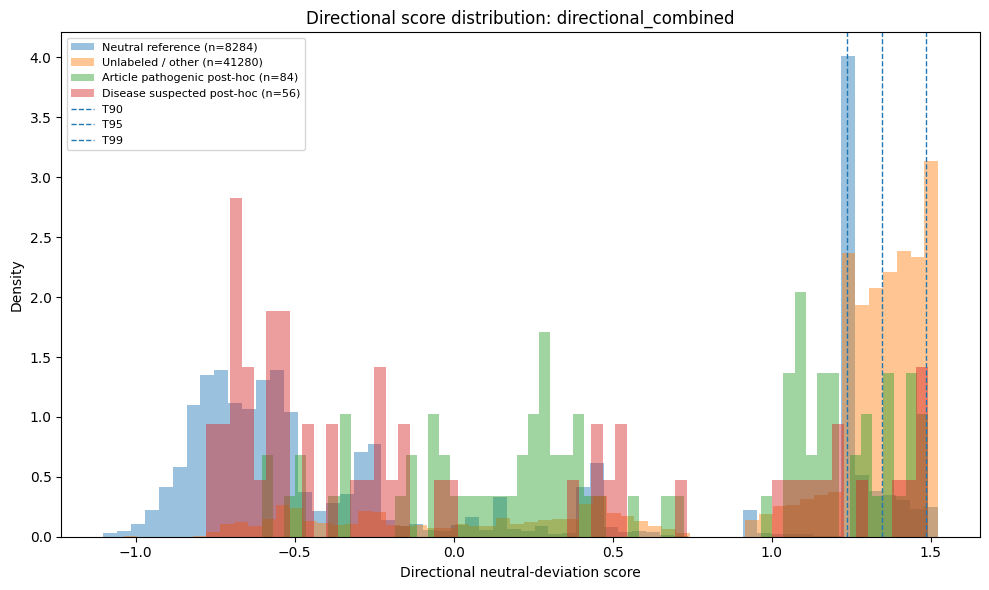

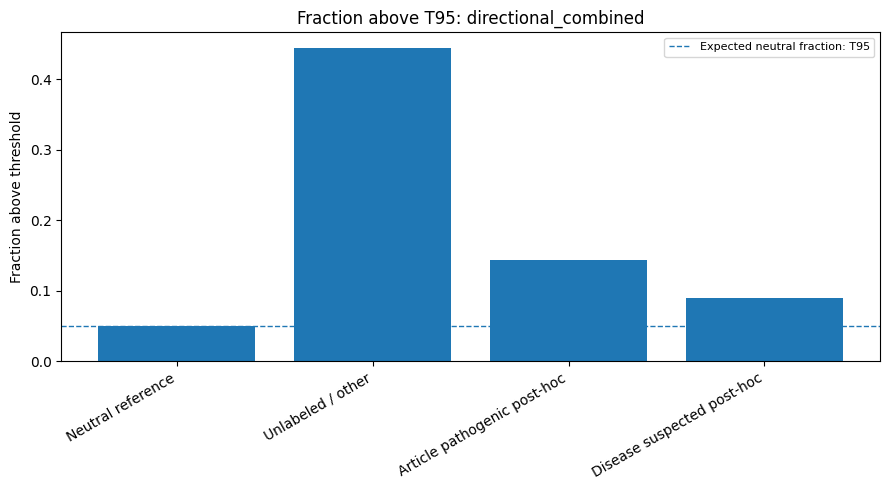

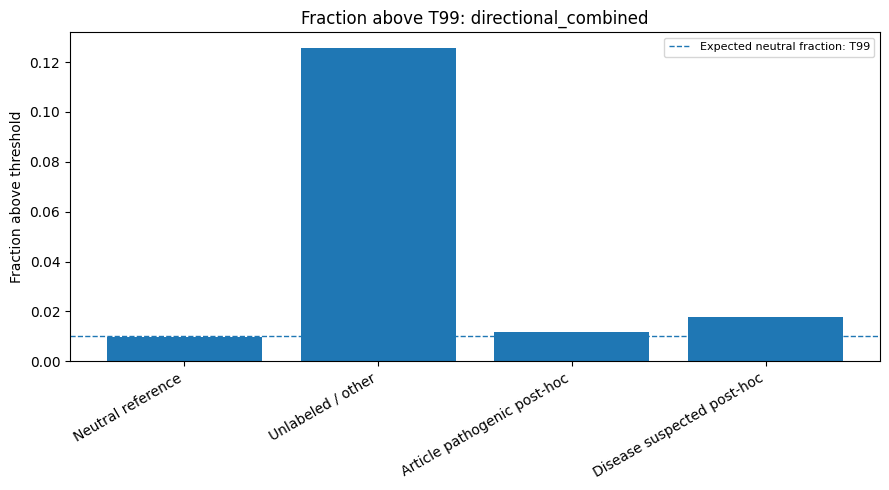

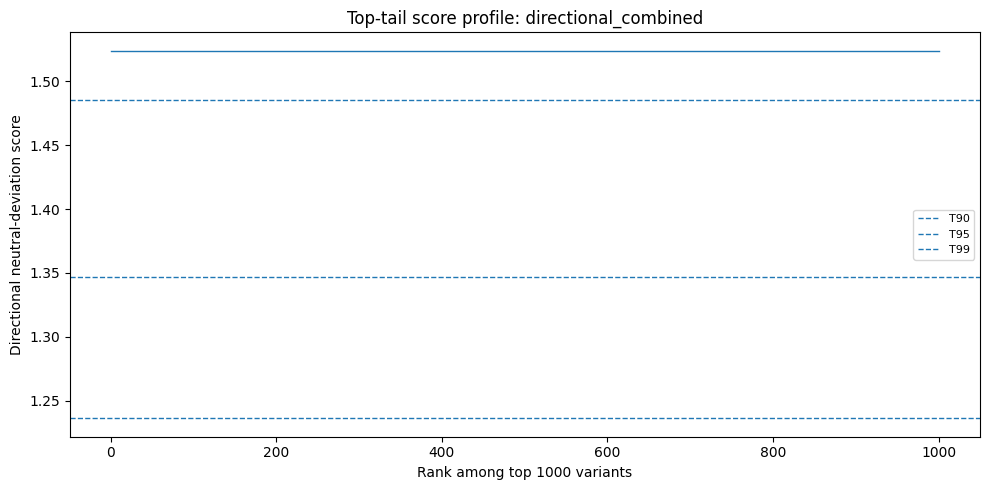

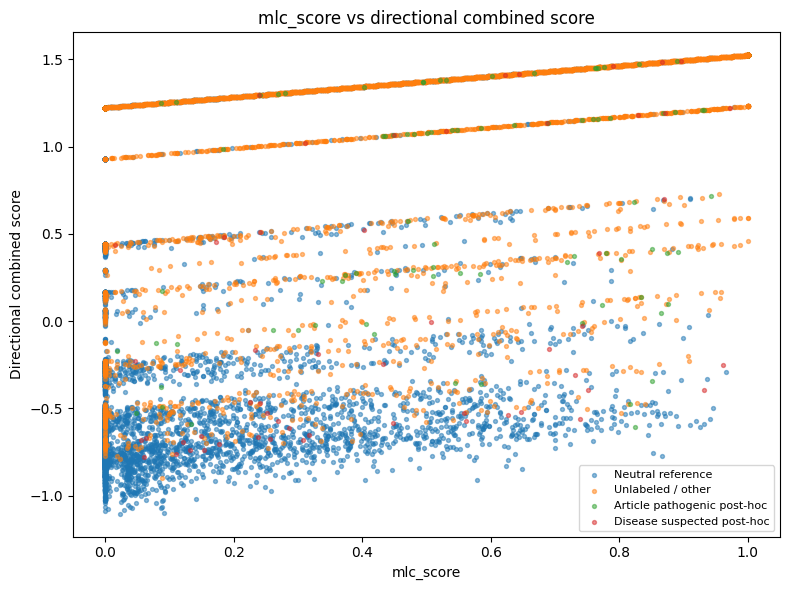

In [52]:
main_score = "directional_combined"

plot_directional_score_distribution(
    scored,
    threshold_df,
    main_score,
)

plot_directional_fraction_above(
    enrichment_df,
    score_name=main_score,
    threshold_name="T95",
)

plot_directional_fraction_above(
    enrichment_df,
    score_name=main_score,
    threshold_name="T99",
)

plot_directional_top_tail(
    scored,
    threshold_df,
    main_score,
    top_n=1000,
)

plot_mlc_vs_directional_combined(scored)

In [53]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# ============================================================
# Directional score v3: compact component-based score
# ============================================================

eps = 1e-6

work["rarity_soft_raw"] = -np.log10(work["pop_af_max"] + eps)
work["rarity_soft_raw"] = work["rarity_soft_raw"].clip(0, 6)

work["no_homoplasmic_component_raw"] = (
    work["pop_af_hom_max"] == 0
).astype(int)

work["mlc_component_raw"] = work["mlc_score"]

component_cols = [
    "mlc_component_raw",
    "rarity_soft_raw",
    "no_homoplasmic_component_raw",
]

neutral_mask = work["analysis_group"] == "neutral_reference"

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(work.loc[neutral_mask, component_cols])

z = pd.DataFrame(
    scaler.transform(work[component_cols]),
    columns=[
        "mlc_component_z",
        "rarity_soft_z",
        "no_homoplasmic_component_z",
    ],
    index=work.index,
)

work = pd.concat([work, z], axis=1)

work["directional_score_v3"] = (
    0.70 * work["mlc_component_z"]
    + 0.25 * work["rarity_soft_z"]
    + 0.05 * work["no_homoplasmic_component_z"]
)

work["directional_score_v3_rank"] = (
    work["directional_score_v3"]
    .rank(method="min", ascending=False)
    .astype(int)
)

work["directional_score_v3_percentile"] = (
    work["directional_score_v3"]
    .rank(method="average", pct=True)
)

In [54]:
# ============================================================
# Thresholds based on neutral_reference
# ============================================================

threshold_rows = []

neutral_scores = work.loc[neutral_mask, "directional_score_v3"]

for q in [0.90, 0.95, 0.99]:
    threshold_name = f"T{int(q * 100)}"
    threshold = neutral_scores.quantile(q)

    flag_col = f"directional_score_v3_above_{threshold_name}"

    work[flag_col] = (
        work["directional_score_v3"] > threshold
    ).astype(int)

    threshold_rows.append({
        "score_name": "directional_score_v3",
        "threshold_name": threshold_name,
        "neutral_quantile": q,
        "threshold_value": threshold,
        "n_neutral_above_threshold": int(work.loc[neutral_mask, flag_col].sum()),
        "fraction_neutral_above_threshold": float(work.loc[neutral_mask, flag_col].mean()),
    })

threshold_df = pd.DataFrame(threshold_rows)

print(threshold_df)

             score_name threshold_name  neutral_quantile  threshold_value  \
0  directional_score_v3            T90              0.90         1.177818   
1  directional_score_v3            T95              0.95         1.775369   
2  directional_score_v3            T99              0.99         2.814295   

   n_neutral_above_threshold  fraction_neutral_above_threshold  
0                        829                          0.100072  
1                        415                          0.050097  
2                         83                          0.010019  


In [55]:
# ============================================================
# Post-hoc enrichment
# ============================================================

posthoc_groups = [
    "neutral_reference",
    "unlabeled_or_other",
    "article_pathogenic_posthoc",
    "disease_suspected_posthoc",
]

enrichment_rows = []

for threshold_name in ["T90", "T95", "T99"]:
    flag_col = f"directional_score_v3_above_{threshold_name}"

    expected = {
        "T90": 0.10,
        "T95": 0.05,
        "T99": 0.01,
    }[threshold_name]

    for group in posthoc_groups:
        group_mask = work["analysis_group"] == group

        n_group = int(group_mask.sum())
        n_above = int(work.loc[group_mask, flag_col].sum())
        frac = n_above / n_group if n_group > 0 else np.nan

        enrichment_rows.append({
            "score_name": "directional_score_v3",
            "threshold_name": threshold_name,
            "analysis_group": group,
            "n_group": n_group,
            "n_above_threshold": n_above,
            "fraction_above_threshold": frac,
            "expected_neutral_fraction": expected,
            "fold_enrichment_vs_neutral_expectation": frac / expected,
        })

enrichment_df = pd.DataFrame(enrichment_rows)

print(enrichment_df)

              score_name threshold_name              analysis_group  n_group  \
0   directional_score_v3            T90           neutral_reference     8284   
1   directional_score_v3            T90          unlabeled_or_other    41280   
2   directional_score_v3            T90  article_pathogenic_posthoc       84   
3   directional_score_v3            T90   disease_suspected_posthoc       56   
4   directional_score_v3            T95           neutral_reference     8284   
5   directional_score_v3            T95          unlabeled_or_other    41280   
6   directional_score_v3            T95  article_pathogenic_posthoc       84   
7   directional_score_v3            T95   disease_suspected_posthoc       56   
8   directional_score_v3            T99           neutral_reference     8284   
9   directional_score_v3            T99          unlabeled_or_other    41280   
10  directional_score_v3            T99  article_pathogenic_posthoc       84   
11  directional_score_v3            T99 

In [57]:
work.head()

,variant_id,position,reference,alternate,validation_label,is_disease_suspected_dataset3,is_neutral_dataset8,is_pathogenic_dataset9,analysis_group,gnomad_combined_af_simple,...,mlc_component_raw,mlc_component_z,rarity_soft_z,no_homoplasmic_component_z,directional_score_v3,directional_score_v3_rank,directional_score_v3_percentile,directional_score_v3_above_T90,directional_score_v3_above_T95,directional_score_v3_above_T99
0,m.1G>T,1,G,T,unlabeled,0,0,0,unlabeled_or_other,0.0,...,0.65755,2.412648,1.289881,1.534225,2.088035,14454,0.709198,1,1,0
1,m.1G>A,1,G,A,unlabeled,0,0,0,unlabeled_or_other,0.0,...,0.65755,2.412648,1.289881,1.534225,2.088035,14454,0.709198,1,1,0
2,m.1G>C,1,G,C,unlabeled,0,0,0,unlabeled_or_other,0.0,...,0.65755,2.412648,1.289881,1.534225,2.088035,14454,0.709198,1,1,0
3,m.2A>T,2,A,T,unlabeled,0,0,0,unlabeled_or_other,0.0,...,0.64832,2.371042,1.289881,1.534225,2.058911,14842,0.701392,1,1,0
4,m.2A>C,2,A,C,unlabeled,0,0,0,unlabeled_or_other,0.0,...,0.64832,2.371042,1.289881,1.534225,2.058911,14842,0.701392,1,1,0


In [56]:
# ============================================================
# Save outputs
# ============================================================

OUTPUT_DIR = Path("../results/directional_neutral_scoring_results_v3")
OUTPUT_DIR.mkdir(exist_ok=True)

score_output = OUTPUT_DIR / "directional_neutral_deviation_scores_v3.tsv"
threshold_output = OUTPUT_DIR / "directional_neutral_deviation_thresholds_v3.tsv"
enrichment_output = OUTPUT_DIR / "directional_posthoc_group_enrichment_v3.tsv"

output_cols = [
    "variant_id",
    "position",
    "reference",
    "alternate",
    "validation_label",
    "is_neutral_dataset8",
    "is_pathogenic_dataset9",
    "is_disease_suspected_dataset3",
    "analysis_group",

    "mlc_score",
    "pop_af_max",
    "pop_af_hom_max",
    "observed_in_any_population_db",

    "mlc_component_raw",
    "rarity_component_raw",
    "not_observed_component_raw",
    "no_homoplasmic_component_raw",

    "mlc_component_z",
    "rarity_component_z",
    "not_observed_component_z",
    "no_homoplasmic_component_z",

    "directional_score_v3",
    "directional_score_v3_rank",
    "directional_score_v3_percentile",
    "directional_score_v3_above_T90",
    "directional_score_v3_above_T95",
    "directional_score_v3_above_T99",
]

work[output_cols].to_csv(score_output, sep="\t", index=False)
threshold_df.to_csv(threshold_output, sep="\t", index=False)
enrichment_df.to_csv(enrichment_output, sep="\t", index=False)

print("Saved:")
print(score_output)
print(threshold_output)
print(enrichment_output)

KeyError: "['rarity_component_raw', 'not_observed_component_raw', 'rarity_component_z', 'not_observed_component_z'] not in index"

In [18]:
top_100 = (
    work[output_cols]
    .sort_values("directional_score_v2", ascending=False)
    .head(100)
)

top_100_path = OUTPUT_DIR / "top_100_directional_score_v2.tsv"
top_100.to_csv(top_100_path, sep="\t", index=False)

print("Saved:")
print(top_100_path)

print(top_100[
    [
        "variant_id",
        "analysis_group",
        "directional_score_v2",
        "mlc_score",
        "pop_af_max",
        "rarity_component_raw",
        "not_observed_component_raw",
        "no_homoplasmic_component_raw",
    ]
].head(30))

Saved:
directional_neutral_scoring_results_v2/top_100_directional_score_v2.tsv
       variant_id      analysis_group  directional_score_v2  mlc_score  \
34070  m.11358C>G  unlabeled_or_other              2.769401        1.0   
15419   m.5141C>G   neutral_reference              2.769401        1.0   
27908   m.9304T>G  unlabeled_or_other              2.769401        1.0   
27913   m.9306T>A  unlabeled_or_other              2.769401        1.0   
10184   m.3396T>G  unlabeled_or_other              2.769401        1.0   
21115   m.7040T>A  unlabeled_or_other              2.769401        1.0   
21116   m.7040T>G  unlabeled_or_other              2.769401        1.0   
10183   m.3396T>A  unlabeled_or_other              2.769401        1.0   
23670   m.7892C>T  unlabeled_or_other              2.769401        1.0   
21139   m.7048C>A  unlabeled_or_other              2.769401        1.0   
21149   m.7051T>G  unlabeled_or_other              2.769401        1.0   
15434   m.5146C>G  unlabeled_or_o